In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import torch

import sae_bench.custom_saes.custom_sae_config as custom_sae_config
import sae_bench.custom_saes.relu_sae as relu_sae
import sae_bench.custom_saes.run_all_evals_custom_saes as run_all_evals_custom_saes
import sae_bench.evals.core.main as core
import sae_bench.evals.sparse_probing.main as sparse_probing
import sae_bench.sae_bench_utils.general_utils as general_utils
from sae_bench.sae_bench_utils.sae_selection_utils import get_saes_from_regex

RANDOM_SEED = 42

output_folders = {
    "absorption": "eval_results/absorption",
    "autointerp": "eval_results/autointerp",
    "core": "eval_results/core",
    "scr": "eval_results/scr",
    "tpp": "eval_results/tpp",
    "sparse_probing": "eval_results/sparse_probing",
    "unlearning": "eval_results/unlearning",
}

# Note: Unlearning is not recommended for models with < 2B parameters and we recommend an instruct tuned model
# Unlearning will also require requesting permission for the WMDP dataset (see unlearning/README.md)
# Absorption not recommended for models < 2B parameters
# asyncio doesn't like notebooks, so autointerp must be ran using a python script

# Select your eval types here.
eval_types = [
    "absorption",
    # "autointerp",
    "core",
    "scr",
    "tpp",
    "sparse_probing",
    # "unlearning",
]

if "autointerp" in eval_types:
    raise ValueError("autointerp must be ran using a python script")

device = general_utils.setup_environment()

model_name = "gemma-2-2b"
llm_batch_size = 512
torch_dtype = torch.float32

# Currently all evals take str_dtype instead of torch_dtype. We did this for serialization purposes, but it was probably a mistake.
# For now we will just use the str_dtype. TODO: Fix this
str_dtype = torch_dtype.__str__().split(".")[-1]


# If evaluating multiple SAEs on the same layer, set save_activations to True
# This will require at least 100GB of disk space
save_activations = False

/scratch/core/lstoepler/dev/SAEBench/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


This cell loads your custom SAEs. If you just want to use existing SAE Lens SAEs, comment it out.


In [ ]:
repo_id = "canrager/lm_sae"
baseline_filename = (
    "pythia70m_sweep_standard_ctx128_0712/resid_post_layer_4/trainer_8/ae.pt"
)
hook_layer = 4
hook_name = f"blocks.{hook_layer}.hook_resid_post"

sae = relu_sae.load_dictionary_learning_relu_sae(
    repo_id, baseline_filename, model_name, device, torch_dtype, layer=hook_layer
)

print(f"sae dtype: {sae.dtype}, device: {sae.device}")

d_sae, d_in = sae.W_dec.data.shape

assert d_sae >= d_in

print(f"d_in: {d_in}, d_sae: {d_sae}")

In our sae object we need to have a CustomSAEConfig. This contains some information which is used by the evals (hook_name, hook_layer, model_name, d_sae, etc). In addition, it contains information that is used by our plotting functions, like number of training tokens and architecture. For example, we should have the sae.cfg.architecture defined if we want to plot multiple SAE architectures.

Note: Everything in this cell, except `architecture` and `training_tokens`, is done in the `BaseSAE` class that the `ReluSAE` inherits from. Because of this, we recommend that you modify an existing SAE class.


In [ ]:
sae.cfg = custom_sae_config.CustomSAEConfig(
    model_name, d_in=d_in, d_sae=d_sae, hook_name=hook_name, hook_layer=hook_layer
)

# Core evals require us to specify cfg.dtype, which must be a string for easy serialization. TODO: Refactor to use torch.dtype
sae.cfg.dtype = str_dtype


# The following contains our current defined SAE types and the shapes to plot for each. Add your custom SAE as new_sae_key
new_sae_key = "vanilla"
trainer_markers = {
    "standard": "o",
    "jumprelu": "X",
    "topk": "^",
    "p_anneal": "*",
    "gated": "d",
    new_sae_key: "s",  # New SAE
}

trainer_colors = {
    "standard": "blue",
    "jumprelu": "orange",
    "topk": "green",
    "p_anneal": "red",
    "gated": "purple",
    new_sae_key: "black",  # New SAE
}

sae.cfg.architecture = new_sae_key
sae.cfg.training_tokens = 200_000_000

`selected_saes` is a list of tuples of (unique_sae_id, sae object) OR (sae lens release, sae lens id). If it is a list of custom sae objects, then memory size will increase with the length of the list. This is especially important if the SAEs are large. If memory is a concern, I recommend calling the `run_eval()` function multiple times with lists of length 1, each list containing a new sae object.


In [ ]:
# Note: the custom_sae_id should be unique, as it is used for the intermediate results and final results file names

unique_custom_sae_id = baseline_filename.replace("/", "_").replace(".", "_")
print(f"sae_id: {unique_custom_sae_id}")

# list of tuple of (sae_id, sae object)
custom_saes = [(unique_custom_sae_id, sae)]

Select your baseline SAEs here. Refer to `sae_regex_selection.ipynb` for more regex patterns. We are going to get a topk SAE from the same layer.


In [ ]:
sae_regex_pattern = r"(sae_bench_pythia70m_sweep_topk_ctx128_0730).*"
sae_block_pattern = r".*blocks\.([4])\.hook_resid_post__trainer_(8)$"

baseline_saes = get_saes_from_regex(sae_regex_pattern, sae_block_pattern)
print(f"baseline_saes: {baseline_saes}")
baseline_sae_id = f"{baseline_saes[0][0]}_{baseline_saes[0][1]}".replace(".", "_")
print(f"baseline_sae_id: {baseline_sae_id}")

selected_saes = custom_saes + baseline_saes

Run time for the next 2 functions is approximately 2 minutes on an RTX 3090.


In [ ]:
# Note: We typically run with n_eval_sparsity_variance_batches=2000, but I have reduced it here for a faster run

_ = core.multiple_evals(
    selected_saes=selected_saes,
    n_eval_reconstruction_batches=200,
    n_eval_sparsity_variance_batches=200,
    eval_batch_size_prompts=32,
    compute_featurewise_density_statistics=True,
    compute_featurewise_weight_based_metrics=True,
    exclude_special_tokens_from_reconstruction=True,
    dataset="Skylion007/openwebtext",
    context_size=128,
    output_folder="eval_results/core",
    verbose=True,
    dtype=str_dtype,
)

In [ ]:
# We do a subset of the sparse probing datasets here for shorter runtime
dataset_names = ["LabHC/bias_in_bios_class_set1"]

# TODO: Add a verbose flag
_ = sparse_probing.run_eval(
    sparse_probing.SparseProbingEvalConfig(
        model_name=model_name,
        random_seed=RANDOM_SEED,
        llm_batch_size=llm_batch_size,
        llm_dtype=str_dtype,
        dataset_names=dataset_names,
    ),
    selected_saes,
    device,
    "eval_results/sparse_probing",
    force_rerun=False,
    clean_up_activations=True,
    save_activations=save_activations,
)

In [3]:
import json

import torch

import sae_bench.sae_bench_utils.graphing_utils as graphing_utils


In [4]:
image_path = "./images"

if not os.path.exists(image_path):
    os.makedirs(image_path)

In [9]:
results_folders = ["./eval_results"]

eval_type = "scr"

eval_folders = []
core_folders = []
for results_folder in results_folders:
    eval_folders.append(f"{results_folder}/{eval_type}")
    core_folders.append(f"{results_folder}/core")

eval_filenames = graphing_utils.find_eval_results_files(eval_folders)
core_filenames = graphing_utils.find_eval_results_files(core_folders)

print(f"eval_filenames: {eval_filenames}")
print(f"core_filenames: {core_filenames}")

eval_filenames: ['./eval_results/scr/_scatch_core_lstoepler_dev_data_half_sparsity_tgt_google_gemma-2-2b_idempotent_resid_post_layer_12_trainer_2_ae.pt_custom_sae_eval_results.json']
core_filenames: ['./eval_results/core/google_gemma-scope-2b-pt-res_layer_20_width_16k_average_l0_71_params.npz_gemmascope_sae_custom_sae_eval_results.json', './eval_results/core/_scatch_core_lstoepler_dev_data_half_sparsity_tgt_google_gemma-2-2b_idempotent_resid_post_layer_12_trainer_2_ae.pt_custom_sae_eval_results.json']


Here we can view the raw results, and we see that both SAEs significantly outperform the residual stream baseline.


In [10]:
eval_results_dict = graphing_utils.get_eval_results(eval_filenames)
core_results_dict = graphing_utils.get_eval_results(core_filenames)

for sae in eval_results_dict:
    eval_results_dict[sae].update(core_results_dict[sae])


print(eval_results_dict)

{'_scatch_core_lstoepler_dev_data_half_sparsity_tgt_google_gemma-2-2b_idempotent_resid_post_layer_12_trainer_2_ae.pt_custom_sae': {'scr_dir1_threshold_2': -0.33517968293248057, 'scr_metric_threshold_2': 0.04846873741625924, 'scr_dir2_threshold_2': 0.05573677796693846, 'scr_dir1_threshold_5': -0.29944893820910956, 'scr_metric_threshold_5': 0.051180385280762256, 'scr_dir2_threshold_5': 0.08503739992671384, 'scr_dir1_threshold_10': -0.3000609072357061, 'scr_metric_threshold_10': 0.1305675799476656, 'scr_dir2_threshold_10': 0.09444968828078158, 'scr_dir1_threshold_20': -0.43389815149376537, 'scr_metric_threshold_20': 0.1051159247023398, 'scr_dir2_threshold_20': 0.0708833284087102, 'scr_dir1_threshold_50': -1.5112671454378348, 'scr_metric_threshold_50': -0.17330250125557417, 'scr_dir2_threshold_50': -0.14609782498848267, 'scr_dir1_threshold_100': -0.5356241057501105, 'scr_metric_threshold_100': -0.24792568037365545, 'scr_dir2_threshold_100': -0.30956219721788114, 'scr_dir1_threshold_500': -

In [12]:
custom_filepath = eval_filenames[0]

with open(custom_filepath) as f:
    custom_sae_eval_results = json.load(f)

k = 1

print(
    f"Custom SAE top {k} accuracy was:",
    custom_sae_eval_results["eval_result_metrics"]["sae"][f"sae_top_{k}_test_accuracy"],
)
print(
    f"LLM residual stream top {k} accuracy was:",
    custom_sae_eval_results["eval_result_metrics"]["llm"][
        f"llm_top_{k}_test_accuracy"
    ],
)

KeyError: 'sae'

We can also plot the metrics, plotting L0 vs Custom Metric or L0 vs Loss Recovered vs Custom metric. We can have different shapes for the SAE type or dictionary size.


KeyError: 'scr_metric_threshold_1'

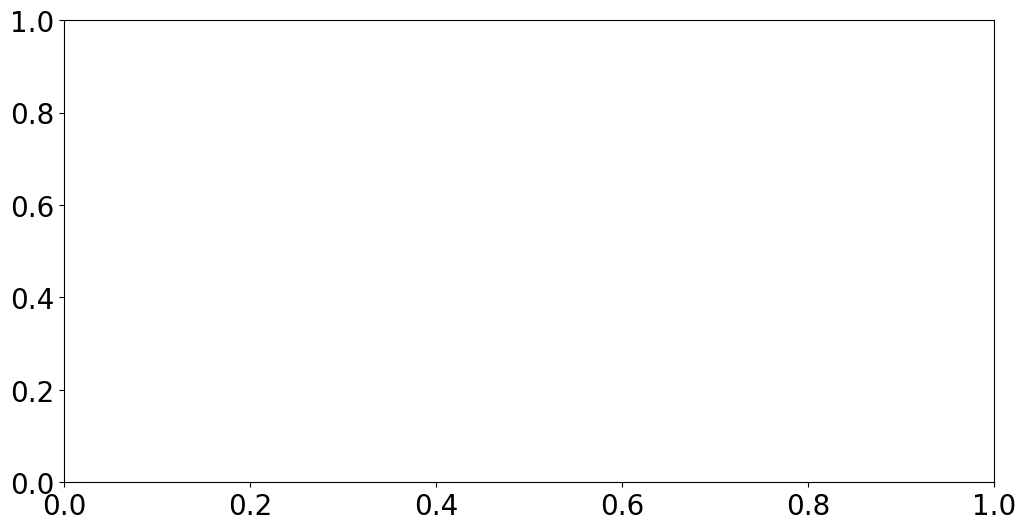

In [15]:
image_base_name = os.path.join(image_path, "sparse_probing")

new_sae_key = "vanilla"
trainer_markers = {
    "standard": "o",
    "jumprelu": "X",
    "topk": "^",
    "p_anneal": "*",
    "gated": "d",
    new_sae_key: "s",  # New SAE
}

trainer_colors = {
    "standard": "blue",
    "jumprelu": "orange",
    "topk": "green",
    "p_anneal": "red",
    "gated": "purple",
    new_sae_key: "black",  # New SAE
}

eval_type = "scr"

graphing_utils.plot_results(
    eval_filenames,
    core_filenames,
    eval_type,
    image_base_name,
    k,
    trainer_markers=trainer_markers,
    trainer_colors=trainer_colors,
)

Now we will run all of the evals, and create more plots. Be warned - this takes around an hour. Note that a significant amount of the costs are one time per layer - for example, with absorption, we have to train a bunch of probes on a given layer. So, if we have multiple SAEs per layer the cost should be much less than 30 minutes per SAE. In addition, to save disk space usage we currently are not saving activations for reuse by multiple SAEs.

Additionally, we can make this faster by evaluating on a subset of the datasets. Sparse probing and Spurious Correlation Removal both have approximately 8 datasets each. We could lower the time by using fewer datasets at the cost of not having as strong of a signal.


In [ ]:
_ = run_all_evals_custom_saes.run_evals(
    model_name,
    selected_saes,
    llm_batch_size,
    str_dtype,
    device,
    eval_types,
    api_key=None,
    force_rerun=False,
    save_activations=save_activations,
)

In [ ]:
for eval_type in eval_types:
    eval_folders = []

    for results_folder in results_folders:
        eval_folders.append(f"{results_folder}/{eval_type}")

    eval_filenames = graphing_utils.find_eval_results_files(eval_folders)

    graphing_utils.plot_results(
        eval_filenames,
        core_filenames,
        eval_type,
        image_base_name,
        k=10,
        trainer_markers=trainer_markers,
        trainer_colors=trainer_colors,
    )